# <center>Project 2 2026</center>

<center>Author: Lewei Xu (23709058)</center>

In this project we work with monthly mean minimum and maximum temperature sequences recorded at weather stations in Western Australia. The training sequences come from Perth Airport, Jandakot Aero and Perth Metro, the validation sequences from Swanbourne, and the test sequences from Bickley. As a result, every model is trained on one group of stations and then tested on a station it has never seen. In this project we will:

1. Train a two-layered GRU network that forecasts the next 12 months in one go. (Section 2)
2. Train the same network to forecast 1 month, then run it in a loop to reach 12 months. (Section 3)
3. Train a GRU encoder-decoder that generates the 12 months autoregressively. (Section 4)
4. Compare the last two models as the prediction horizon grows from 12 to 24 months. (Section 5)
5. Train a variational autoencoder to synthesize maximum temperature sequences. (Section 6)

### Environment, Hardware, and Running the Notebook

This project was developed and run on the following setup, and the timings reported are specific to this hardware:

1. GPU: nvidia rtx 5070 12gb (blackwell 12.0)
2. CPU/RAM: Intel core ultra 7 265K, 20 cores, 64gb RAM
3. OS: Ubuntu on WSL2, NVIDIA driver 591.86
4. Software versions: Python 3.12.13, TensorFlow 2.21.0 (conda build CUDA 13.0), Keras 3.15.0

TensorFlow 2.21 was used instead of the specified 2.20 in the unit's yaml configuration due to incompatibility with rtx5070 sm_120 (TensorFlow 2.20 only works with sm_60 to sm_90). The code itself however should not be specific to hardware or environment, so as long as a compatible environment is installed, this notebook should run.

## Section 1: Setup and Data

In this section, we will load the .pkl file, check the sequence lengths, split them into inputs and targets, and build the plotting function that will be reused in later sections.

### Section 1.1: Imports and Data Loading

First, we will make the necessary imports, set seed for reproducibility, and define the constants used throughout the project. ``INPUT_LENGTH`` and ``TARGET_LENGTH`` are the 72 and 12 months asked for by the project spec, ``SCALE`` is the constant we divide temperatures by (explained in Section 2.1), and ``N_UNITS`` and ``LEARNING_RATE`` are the width of each GRU layer and the Nadam learning rate.

**NOTE:** all 3 GRU models in this project share the same hyperparameters: ``N_UNITS`` neurons per GRU layer, ``LEARNING_RATE``, Huber loss, the Nadam optimizer, ``tanh`` activation, and the same scaling constant. This is deliberate, so that the comparison in Section 5 shows the difference between the three architectures rather than the result of tuning one of them harder than the others. At this learning rate, all 3 models are still improving slowly at epoch 100, so early stopping rarely occurs and mostly serves to restore the best epoch's weights.

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

tf.keras.utils.set_random_seed(42)

INPUT_LENGTH = 72
TARGET_LENGTH = 12
SCALE = 40.
N_UNITS = 16
LEARNING_RATE = 0.005

I0000 00:00:1790066093.672116   52425 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790066093.846547   52425 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Now we will load the pickle file with the function provided in the project specification.

In [3]:
def load_data(picklefile):
    import pickle
    f = open(picklefile, "rb")
    data = pickle.load(f)
    f.close()
    return data

(train_seq, val_seq, test_seq) = load_data("temperatures-2026.pkl")

print(f"train_seq: {train_seq.shape}  val_seq: {val_seq.shape}  test_seq: {test_seq.shape}")
print(f"type: {type(train_seq).__name__}  dtype: {train_seq.dtype}")

train_seq: (1522, 84, 2)  val_seq: (313, 84, 2)  test_seq: (297, 96, 2)
type: EagerTensor  dtype: <dtype: 'float32'>


I0000 00:00:1790066098.455883   52425 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9216 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5070, pci bus id: 0000:02:00.0, compute capability: 12.0a


Here we can see that the shapes match the project spec. Before going further, let's do some simple data exploration.

In [4]:
sets = {"train": train_seq, "val": val_seq, "test": test_seq}
pd.DataFrame({
    "sequences": [s.shape[0] for s in sets.values()],
    "months": [s.shape[1] for s in sets.values()],
    "mean min": [float(tf.reduce_mean(s[:, :, 0])) for s in sets.values()],
    "mean max": [float(tf.reduce_mean(s[:, :, 1])) for s in sets.values()],
    "lowest": [float(tf.reduce_min(s)) for s in sets.values()],
    "highest": [float(tf.reduce_max(s)) for s in sets.values()],
}, index=sets.keys()).round(2)

,sequences,months,mean min,mean max,lowest,highest
train,1522,84,12.23,24.70,3.8,36.3
val,313,84,14.04,24.11,7.6,34.0
test,297,96,11.32,22.63,5.3,33.8


Here we can see that every temperature in the data sits in the expected range of regular Perth weather (roughly 4 to 36 °C). The minimum and maximum components are on the same scale, so we can treat each sequence as a two channel 1D image instead of 2 unrelated features, which is what motivates the scaling decision in Section 2.1.

Additionally, the three sets show different climates. For example, Bickley, the test station, is the coolest of the three at about 2 degrees below the training mean maximum. The sets also differ in how their minimums and maximums sit relative to each other, with the validation set having a comparatively higher minimum temperature. As such, every MAE reported in this project will be a transfer result, measured on a station whose climate no model was trained on. The validation and test set are not measuring the exact same kind of shifts as each other (although they would be similar as they are all in the same general geographic region).

### Section 1.2: Splitting the Sequences

We will now split the training and validation sequences into 72 months of input and 12 months of predictions. The test sequences are 96 months long, so the remaining 12 months of sequences are not used until Section 5, when we compare the models from Sections 3 and 4.

In [5]:
def split_sequences(sequences, input_length=INPUT_LENGTH, target_length=TARGET_LENGTH):
    X = sequences[:, :input_length]
    y = sequences[:, input_length:input_length + target_length]
    return X, y

X_train, y_train = split_sequences(train_seq)
X_val, y_val = split_sequences(val_seq)
X_test, y_test = split_sequences(test_seq)

for name, X, y in [("train", X_train, y_train), ("val", X_val, y_val), ("test", X_test, y_test)]:
    print(f"{name}: X {X.shape}  y {y.shape}")

train: X (1522, 72, 2)  y (1522, 12, 2)
val: X (313, 72, 2)  y (313, 12, 2)
test: X (297, 72, 2)  y (297, 12, 2)


### Section 1.3: Visualising the Sequences

Finally, we will construct the ``display_temperatures`` function that samples 3 sequences at random, rejoins each input with its target, and plots the minimum and maximum series together. The dotted line marks where the forecast begins.

Two optional arguments allow this function to be reusable for later sections in this project. ``y_pred`` overlays predictions on the target region as crosses and puts that sequence's MAE in the subplot title, and ``indices`` allows the function to display specific sequences instead of random ones.

In [6]:
def display_temperatures(X, y, title, y_pred=None, indices=None, n_seqs=3, seed=42):

    # Sample sequences at random unless specific ones were asked for
    if indices is None:
        rng = np.random.default_rng(seed)
        indices = rng.choice(X.shape[0], size=n_seqs, replace=False)
    indices = np.asarray(indices)[:n_seqs]

    input_length = X.shape[1]
    months = np.arange(input_length + y.shape[1])
    future = months[input_length:]

    fig, axes = plt.subplots(1, len(indices), figsize=(16, 3.6), squeeze=False)
    for ax, index in zip(axes[0], indices):
        combined = tf.concat([X[index], y[index]], axis=0)
        ax.plot(months, combined[:, 0], color="tab:blue", label="minimum")
        ax.plot(months, combined[:, 1], color="tab:red", label="maximum")
        ax.axvline(input_length - 0.5, color="black", linestyle=":")

        subtitle = f"sequence {index}"
        if y_pred is not None:
            ax.plot(future, y_pred[index][:, 0], "x--", color="tab:cyan",
                    label="minimum predicted")
            ax.plot(future, y_pred[index][:, 1], "x--", color="tab:orange",
                    label="maximum predicted")
            subtitle += f", MAE {float(tf.reduce_mean(tf.abs(y[index] - y_pred[index]))):.2f}"

        ax.set_title(subtitle)
        ax.set_xlabel("month")
        ax.set_ylabel("temperature (°C)")
        ax.grid(True)

    # One legend under the whole figure, so it never sits on top of a series
    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=len(labels))
    fig.suptitle(title)
    fig.tight_layout(rect=[0, 0.09, 1, 1])
    plt.show()

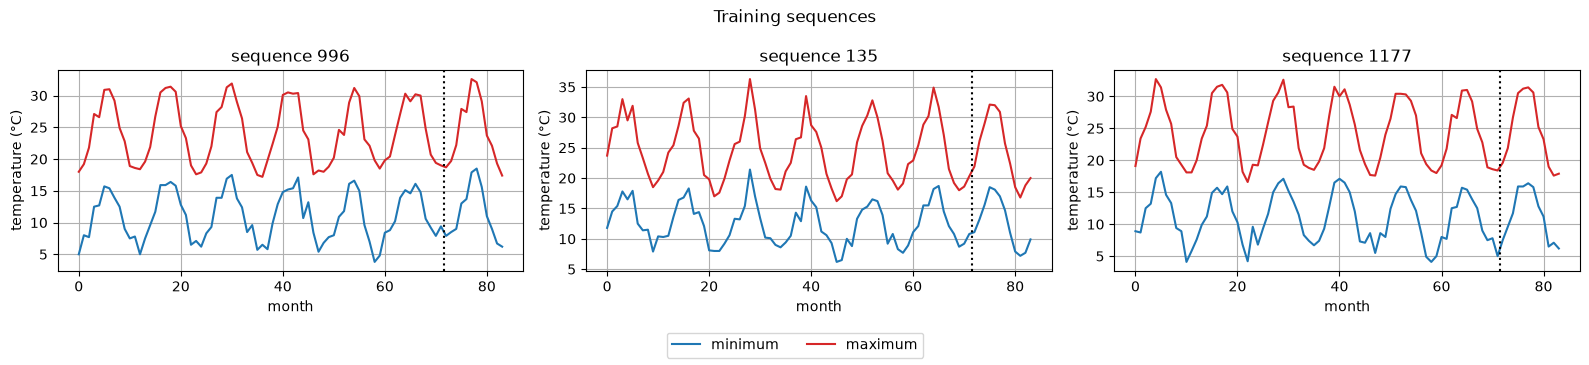

In [7]:
display_temperatures(X_train, y_train, "Training sequences")

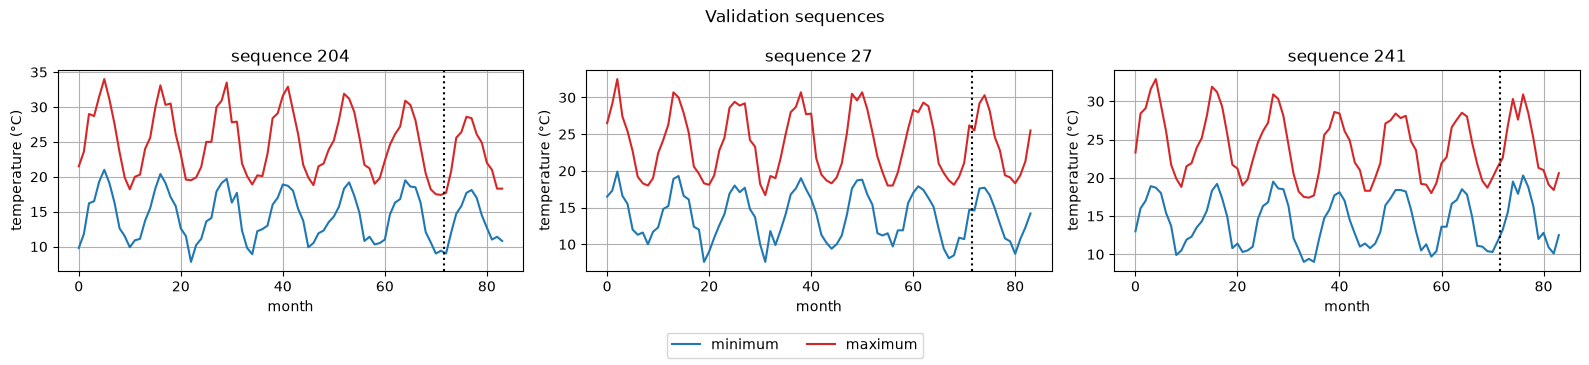

In [8]:
display_temperatures(X_val, y_val, "Validation sequences")

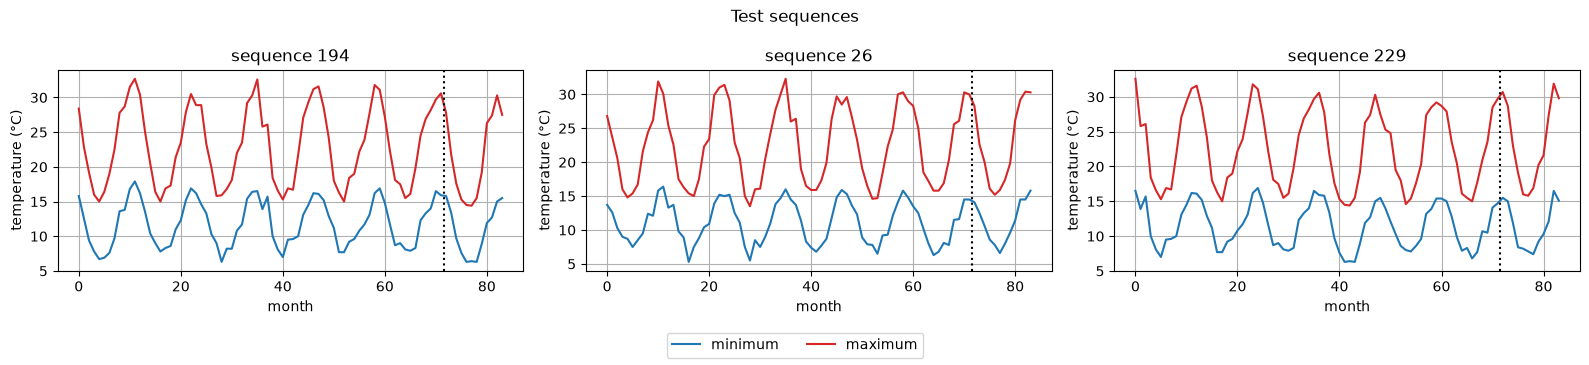

In [9]:
display_temperatures(X_test, y_test, "Test sequences")

In all three sets, we can see the same strong annual cycle (as expected), with the minimum and maximum series rising and falling together. Each 72 month input covers 6 complete cycles (years), which should give the model plenty of repetitions to learn the shape from. What may be difficult to predict however is the height/amplitude of the cycle rather than the actual shape.

## Section 2: Model 1, Direct 12-Month Forecast

In this section, we will implement a model to predict the following 12 months' mean minimum and maximum temperatures in one go.

### Section 2.1: Network Architecture

Model 1 consists of two GRU layers, each with 16 units, and a ``Dense`` layer with 24 outputs (corresponding to the 12 months of predictions for min and max temperatures respectively), then a ``Reshape`` layer to produce the final 12 by 2 target shape. Only the second GRU layer's final output is needed, so we use ``return_sequences=True`` only on the first GRU layer.

The problem with a GRU/RNN is that the default activation is ``tanh``, which squashes each layer's output to [-1, 1]. Our temperature values range from 4-36 degrees, so feeding these values straight into the network and asking the linear ``Dense`` layer to recover the degrees won't work very well. Via some testing, we found that the network settled at ~3.6 degrees MAE, which is roughly the same as predicting a flat average. Testing various learning rates did not fix this issue.

There are two solutions to this problem: either use ``relu`` activation, which leaves hidden states unbounded so that temperature values can pass straight through, or keep the default ``tanh`` and instead use scaling to put the data into the activation range. For the scaling solution, we used a constant ``Rescaling(1. / SCALE)`` (``SCALE = 40.`` defined in Section 1.1) which is just above the highest temperature in the data, putting every value into roughly 0.1 to 0.9. Through various testing and hyperparameter tuning, we found that using ``tanh`` with scaling and a learning rate of 0.005 produced slightly better results at 1.12 degrees MAE compared to 1.18 degrees MAE using ``relu``. Implemented below is the model using this setup.

We use a constant scaling factor which is the same thing as dividing image pixels by 255. The relationship between the minimum and maximum series, and between one month and the next, remains the same, and there is no per-feature standardisation of the kind the project specification warns against. The targets are divided by the same constant, and we scale the MAE Keras reports back up so that every number in this notebook is in degrees Celsius.

In [10]:
y_train_scaled = y_train / SCALE
y_val_scaled = y_val / SCALE

def mae_degrees(y_true, y_pred):
    # The network works in scaled units, so multiply back to report the MAE in degrees
    return tf.reduce_mean(tf.abs(y_true - y_pred)) * SCALE

def build_gru_model(target_length, n_units=N_UNITS, input_length=INPUT_LENGTH,
                    learning_rate=LEARNING_RATE):
    tf.keras.utils.set_random_seed(42)

    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=[input_length, 2]),
        tf.keras.layers.Rescaling(1. / SCALE),
        tf.keras.layers.GRU(n_units, return_sequences=True),
        tf.keras.layers.GRU(n_units),
        tf.keras.layers.Dense(target_length * 2),
        tf.keras.layers.Reshape([target_length, 2]),
    ])
    model.compile(loss=tf.keras.losses.Huber(),
                  optimizer=tf.keras.optimizers.Nadam(learning_rate=learning_rate),
                  metrics=[mae_degrees])
    return model

model_1 = build_gru_model(TARGET_LENGTH)
model_1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 72, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 72, 16)         │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 16)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 24)             │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 12, 2)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000 (11.72 KB)

 Trainable params: 3,000 (11.72 KB)

 Non-trainable params: 0 (0.00 B)

### Section 2.2: Training

Here we define three helper functions that can be reused across all 3 models. 

``train_model`` runs 100 epochs with early stopping on the validation MAE with ``restore_best_weights=True`` so the weights we keep are the best ones seen during training. ``X`` can also be passed as a list to let this same function train the two input encoder-decoder in Section 4.

``plot_learning_curve`` plots two learning curves, one for loss and one for MAE. We separate loss and MAE as they are on different scales and not comparable with each other.

``forecast`` runs a model and undoes the target scaling so that the numbers it returns are in degrees.

In [11]:
def train_model(model, X, y, X_valid, y_valid, epochs=100, patience=15):
    # mode="min" is required because Keras cannot infer the direction of a custom metric
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor="val_mae_degrees", mode="min",
                                                      patience=patience,
                                                      restore_best_weights=True)
    return model.fit(X, y, epochs=epochs, validation_data=(X_valid, y_valid),
                     callbacks=[early_stopping], verbose=0)

def plot_learning_curve(history, title):
    curves = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    curves[["loss", "val_loss"]].plot(ax=axes[0], grid=True, xlabel="Epoch", ylabel="loss")
    curves[[c for c in curves.columns if "mae" in c]].plot(ax=axes[1], grid=True, xlabel="Epoch", ylabel="MAE (°C)")
    fig.suptitle(f"{title} ({len(curves)} epochs)")
    plt.tight_layout()
    plt.show()

def forecast(model, X):
    return model(X, training=False) * SCALE

Let's now train our first model and plot the learning curves:

I0000 00:00:1790066101.408581   76870 cuda_dnn.cc:461] Loaded cuDNN version 92301


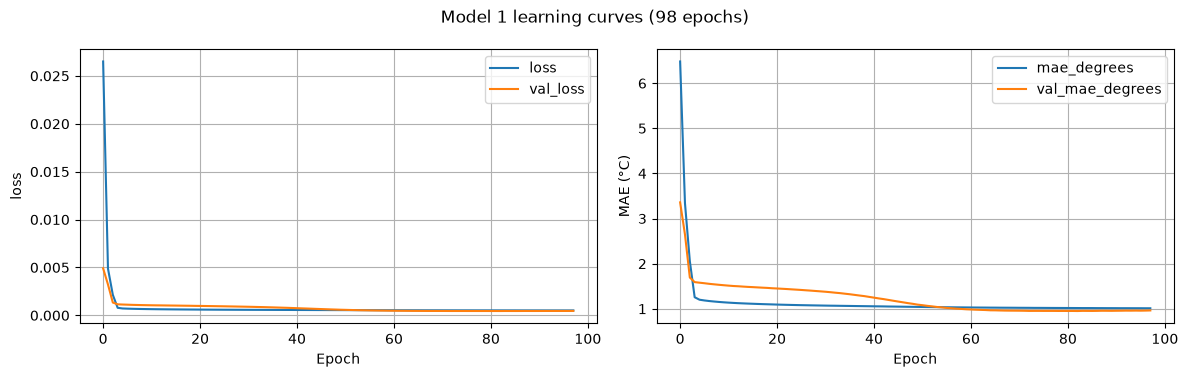

In [12]:
history_1 = train_model(model_1, X_train, y_train_scaled, X_val, y_val_scaled)
plot_learning_curve(history_1, "Model 1 learning curves")

Here we can see that training went quite well. Both curves drop almost vertically over the first two or three epochs, from an MAE of about 6.5 degrees down to roughly 1.3. Everything after that is a long slow grind from 1.3 to just under 1.0 spread over the remaining 90-ish epochs. The validation MAE sits above the training MAE until about epoch 55 and then crosses below it, indicating that overfitting did not occur and the model generalises well. This may be because the training sequences came from 3 different stations compared to just one station for the validation set. From the plot, training reached 98 epochs before early stopping fired, indicating that the training budget was almost used up, and the callback's main contribution was just restoring the best epoch's weights.

### Section 2.3: Test Set Performance

Now we can apply the model to the test sequences. We additionally define an ``evaluate_mae`` helper function to reuse for MAE calculation in later sections. The function averages over both temperature channels and all target months at once so all MAE calculations occur in the same way, and it still works later on where forecasts are not produced by ``model.predict``.

In [13]:
def evaluate_mae(y_true, y_pred):
    return float(tf.reduce_mean(tf.abs(y_true - y_pred)))

y_pred_1 = forecast(model_1, X_test)
mae_1 = evaluate_mae(y_test, y_pred_1)
print(f"Model 1 test MAE: {mae_1:.4f} °C")

Model 1 test MAE: 1.1243 C


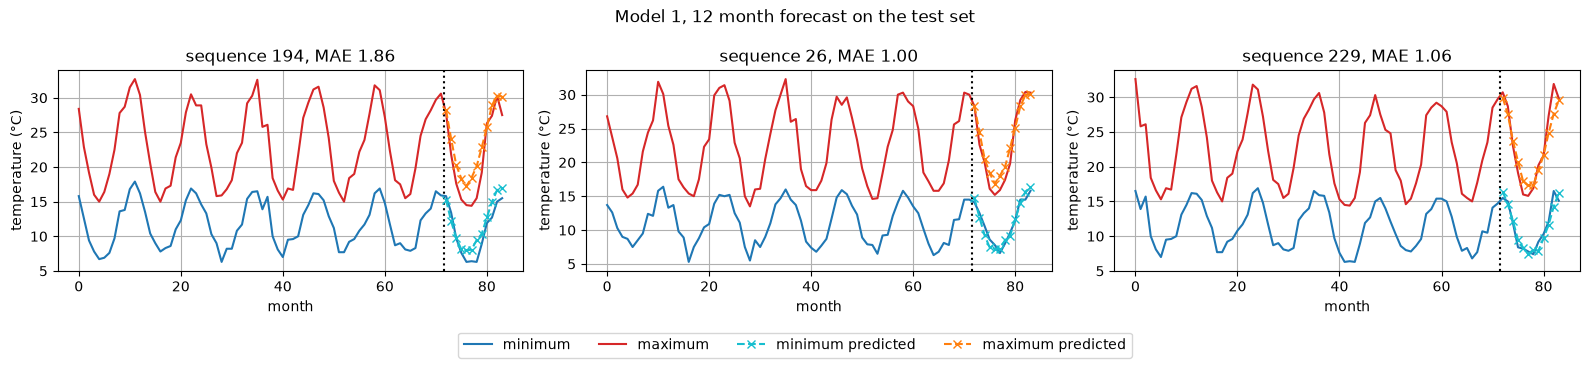

In [14]:
display_temperatures(X_test, y_test, "Model 1, 12 month forecast on the test set", y_pred=y_pred_1)

As per Section 2.1, the model reaches an MAE of 1.12 degrees on Bickley station, a station it has never been trained on. Using our ``display_temperatures`` function, we can see that the predictions get the shape and timing of the annual cycle correct, but the curves are visibly smoother than the real ones, and sometimes the amplitude does not match the real temperatures. This can be seen in sequence 194, where the model predicts a shallower winter trough than actually occurred.

## Section 3: Model 2, One-Month Forecast

In this section, we will implement the same model as Model 1 but instead predict for only one month at a time, then use the model's own outputs to predict up to 12 months.

### Section 3.1: Architecture and Training

Model 2 is the same network with the output layer changed to a single month. We will reuse the ``build_gru_model`` function using the ``target_length`` argument to produce this model: the ``Dense`` layer drops from 24 neurons to 2 and the ``Reshape`` layer becomes 1x2 instead. We use the same training set but with the targets truncated to only the first month for training.

In [ ]:
y_train_1m, y_val_1m = y_train_scaled[:, :1], y_val_scaled[:, :1]
y_test_1m = y_test[:, :1]   # left in degrees, like every other test target

model_2 = build_gru_model(1)
model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 72, 2)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 72, 16)         │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 16)             │         1,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            34 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 1, 2)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,626 (10.26 KB)

 Trainable params: 2,626 (10.26 KB)

 Non-trainable params: 0 (0.00 B)

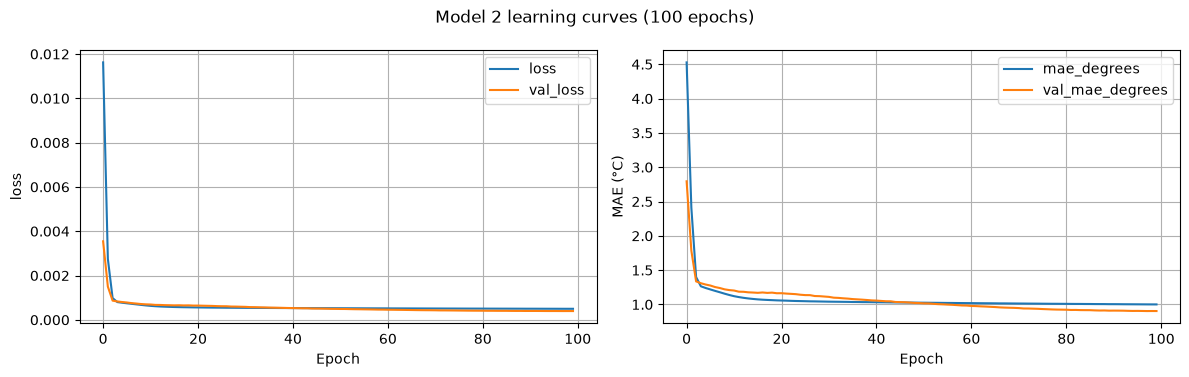

In [ ]:
history_2 = train_model(model_2, X_train, y_train_1m, X_val, y_val_1m)
plot_learning_curve(history_2, "Model 2 learning curves")

Evidently, predicting a single month is an easier job than predicting 12, especially with the same architecture (same 16 neurons across 2 GRU layers). The MAE starts lower and settles lower, ending at about 1.0 degrees on the training set and 0.9 on the validation set. The shape of the curves are otherwise the same as Model 1, with the validation MAE dipping below the training MAE at around epoch 50, although the validation MAE is significantly closer to the training MAE compared to Model 1. The validation MAE was still improving at epoch 100, so this model used the full training budget and early stopping did not occur.

### Section 3.2: One-Month Test Performance

First we evaluate the model on the job it was actually trained for: predicting one month into the future.

In [ ]:
y_pred_2_1m = forecast(model_2, X_test)
mae_2_1m = evaluate_mae(y_test_1m, y_pred_2_1m)
print(f"Model 2 test MAE, 1 month: {mae_2_1m:.4f} °C")

Model 2 test MAE, 1 month: 0.9472 °C


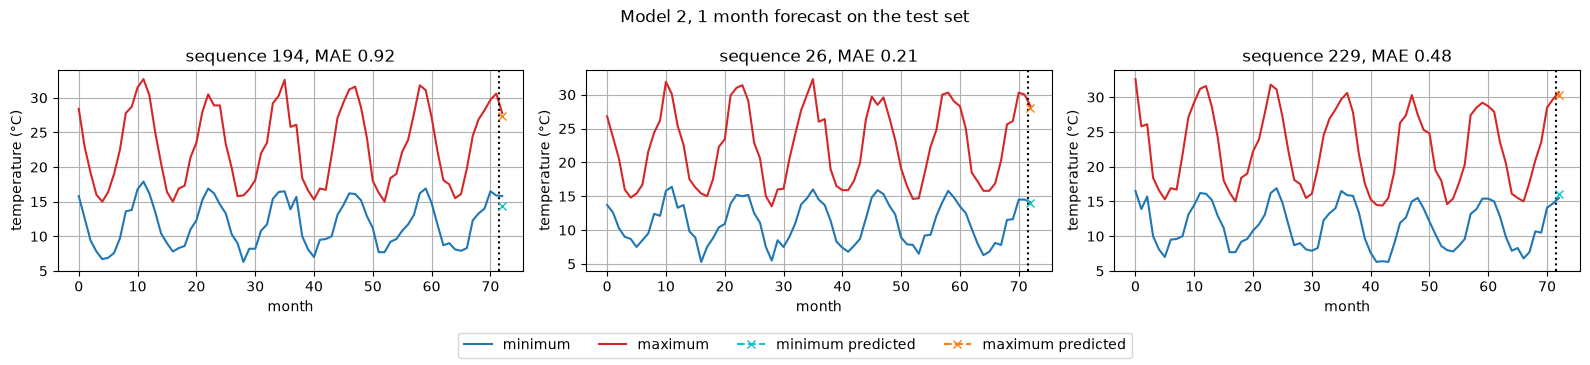

In [ ]:
display_temperatures(X_test, y_test_1m, "Model 2, 1 month forecast on the test set",
                     y_pred=y_pred_2_1m)

On the single month it was actually trained for, the model reaches 0.95 degrees on the test set. This is the lowest MAE we have seen thus far, and is to be expected as we are predicting just a single data point from 72 previous real observations.

### Section 3.3: Forecasting 12 Months with a Loop

To predict 12 months into the future, we call the model repeatedly and feed each prediction it produced back as if it were a real observation. Because the model was trained to predict one month from 72 previous months, we drop the oldest month after appending each newest prediction so that the model is always predicting from 72 observations. As such, rather than letting the window grow, we slide it, which should help to produce better predictions. 

Below, we define the ``forecast_recursively`` function that performs the above. The function reuses the ``forecast`` function defined earlier, which already returns the predictions in degrees Celsius. We additionally provide a ``horizon`` argument so that we can reuse this function in Section 5.

In [ ]:
def forecast_recursively(model, X, horizon):
    # Predict one month at a time, sliding the input window forward with each prediction
    X_window = X
    steps = []
    for _ in range(horizon):
        step = forecast(model, X_window)
        steps.append(step)
        X_window = tf.concat([X_window[:, 1:], step], axis=1)
    return tf.concat(steps, axis=1)

y_pred_2 = forecast_recursively(model_2, X_test, TARGET_LENGTH)
mae_2 = evaluate_mae(y_test, y_pred_2)
print(f"Model 2 test MAE, 12 months by looping: {mae_2:.4f} °C")

Model 2 test MAE, 12 months by looping: 1.0876 °C


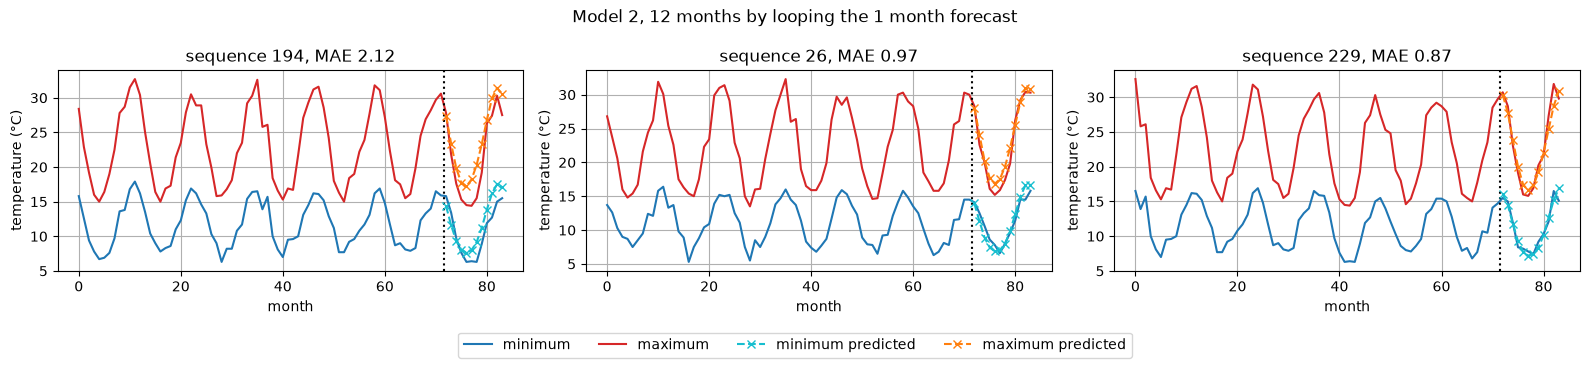

In [ ]:
display_temperatures(X_test, y_test, "Model 2, 12 months by looping the 1 month forecast",
                     y_pred=y_pred_2)

Looping Model 2 twelve times gives us 1.09 degrees MAE compared to model 1's 1.12 on exactly the same task. This is an interesting result; the loop arrangement ought to be a disadvantage as incorrect predictions can propagate into future predictions (it is reading its own predictions instead of real observations from the second step onwards).

We can see exactly this happening in sequence 194, where the model's min/max temperature tapered off instead of continuing to decrease at around month 75, however, for the other sequences we sampled, the predictions are smooth and very close to the actual observations. The annual cycle is strong enough that even when the model is slightly wrong about one month, it barely affects the predictions on the later months. It seems that training the model one month at a time let us teach it a single well defined task, instead of spreading its learning capacity across 12 different outputs.

## Section 4: Model 3, GRU Encoder-Decoder

In this section, we will implement a GRU encoder-decoder model. Unlike Model 2, which loops a one month model, this model trains on all 12 months at once but still generates them one at a time when predicting.

### Section 4.1: Network Architecture

Model 3 is two networks joined by two vectors, so it is worth being explicit about what passes between them.

The **encoder** is just Model 1's pair of GRU layers. The first layer walks along all 72 input months, updating a 16 number hidden state as it goes. ``return_sequences=True`` passes all 72 of those states up to the second layer, and ``return_state=True`` also hands out the last one as ``state_1``. The second layer then walks along the first layer's outputs keeping its own 16 number state, and we keep only its final value as ``state_2``. Everything else the encoder computed is discarded, so what actually leaves it is 32 numbers.

The **decoder** is an ordinary two layer stacked GRU, wired the same way the encoder is: the first layer takes the decoder input sequence, and the second layer takes the first layer's output sequence. The only difference from a normal stack is where each layer's recurrence begins. Instead of both layers starting from a hidden state of zero, the first starts at ``state_1`` and the second at ``state_2``, which is what the ``initial_state`` argument does. This is also the reason the decoder needs two GRU layers rather than one: there are two encoder states to consume, one per encoder layer. A ``Dense`` layer of 2 units on top then reads a minimum and a maximum off every decoder step.

So the encoder's job is to summarise the 72 months it was given into two state vectors, and the decoder's job is to unpack those vectors into 12 months of predictions. Note that ``initial_state`` is not a second data input, it only sets the starting value of the hidden state.

It is worth asking why only the **final** state is passed rather than the whole 72 step sequence. Partly it is that ``initial_state`` is the value of the hidden state at the step before the sequence begins, so it is one vector per layer and handing it a sequence is a shape error rather than a design option. Passing the full sequence is what an attention mechanism does, which is outside what this project asks for. It also does not look like the limiting factor here: Model 1 compresses the same 72 months into a single 16 number state and still scores better than this model does, so the size of the summary is not what holds Model 3 back.

One line in the code below looks like a mistake but is not. In ``_, state_2 = ...`` the discarded ``_`` holds the same numbers as ``state_2``. For a GRU the hidden state and the output are the same thing (unlike an LSTM, which also carries a separate cell state), so with ``return_sequences=False`` Keras returns the final output and the final state, and those are identical.

The decoder's input is the sequence it is being asked to continue, shifted back by one month, which is what ``shift_targets`` builds: the last observed month followed by all but the last target month. Lining up the 12 steps:

| decoder step | input month | output predicts |
|---|---|---|
| 0 | 72 (last observed) | 73 |
| 1 | 73 | 74 |
| ... | ... | ... |
| 11 | 83 | 84 |

During training every one of those inputs is ground truth, which is the usual teacher forcing setup and is what lets all 12 months train in a single forward pass rather than in a loop. Shifting back by one month is also what stops the model cheating: a GRU only ever sees inputs up to the current step, so the output predicting month 73+t sees at most month 72+t, never the month it is being asked for. At test time the ground truth does not exist, so the decoder has to be fed its own predictions instead, which Section 4.3 handles.

Finally, two smaller details. The decoder's input layer is declared with shape ``[None, 2]`` instead of a fixed length, so the trained model can be run for any number of steps, which is what Section 5 needs. And the same ``Rescaling`` layer is applied to both the encoder and the decoder inputs, so the model takes real temperatures at both of its inputs while working internally in scaled units. Only the training targets are divided by ``SCALE`` by hand.

In [ ]:
def build_encoder_decoder(n_units=N_UNITS, input_length=INPUT_LENGTH,
                          learning_rate=LEARNING_RATE):
    tf.keras.utils.set_random_seed(42)

    encoder_inputs = tf.keras.layers.Input(shape=[input_length, 2])
    decoder_inputs = tf.keras.layers.Input(shape=[None, 2])
    rescaling = tf.keras.layers.Rescaling(1. / SCALE)

    # Encoder: keep the hidden state of both GRU layers
    encoder_outputs, state_1 = tf.keras.layers.GRU(n_units, return_sequences=True, return_state=True)(rescaling(encoder_inputs))
    _, state_2 = tf.keras.layers.GRU(n_units, return_state=True)(encoder_outputs)

    # Decoder: a normal 2-layer stack, but each layer starts from the matching encoder state
    decoder_outputs = tf.keras.layers.GRU(n_units, return_sequences=True)(rescaling(decoder_inputs), initial_state=state_1)
    decoder_outputs = tf.keras.layers.GRU(n_units, return_sequences=True)(decoder_outputs, initial_state=state_2)
    outputs = tf.keras.layers.Dense(2)(decoder_outputs)

    model = tf.keras.Model(inputs=[encoder_inputs, decoder_inputs], outputs=[outputs])
    model.compile(loss=tf.keras.losses.Huber(),
                  optimizer=tf.keras.optimizers.Nadam(learning_rate=learning_rate),
                  metrics=[mae_degrees])
    return model

def shift_targets(X, y):
    # Decoder inputs: the last observed month followed by all but the last target month
    return tf.concat([X[:, -1:], y[:, :-1]], axis=1)

model_3 = build_encoder_decoder()
model_3.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, None, 2)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_2       │ (None, 72, 2)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, None, 2)   │          0 │ input_layer_2[0]… │
│ (Rescaling)         │                   │            │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_4 (GRU)         │ [(None, 72, 16),  │        960 │ rescaling_2[0][0] │
│                     │ (None, 16)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_6 (GRU)         │ (None, None, 16)  │        960 │ rescaling_2[1][0… │
│                     │                   │            │ gru_4[0][1]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_5 (GRU)         │ [(None, 16),      │      1,632 │ gru_4[0][0]       │
│                     │ (None, 16)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru_7 (GRU)         │ (None, None, 16)  │      1,632 │ gru_6[0][0],      │
│                     │                   │            │ gru_5[0][1]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, None, 2)   │         34 │ gru_7[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,218 (20.38 KB)

 Trainable params: 5,218 (20.38 KB)

 Non-trainable params: 0 (0.00 B)

### Section 4.2: Training

Training reuses ``train_model`` from Section 2.2 with the encoder and decoder inputs passed as a list. Note that ``shift_targets`` is called on the unscaled targets, because the decoder input goes through the model's ``Rescaling`` layer like any other input, while the fit target is the scaled one.

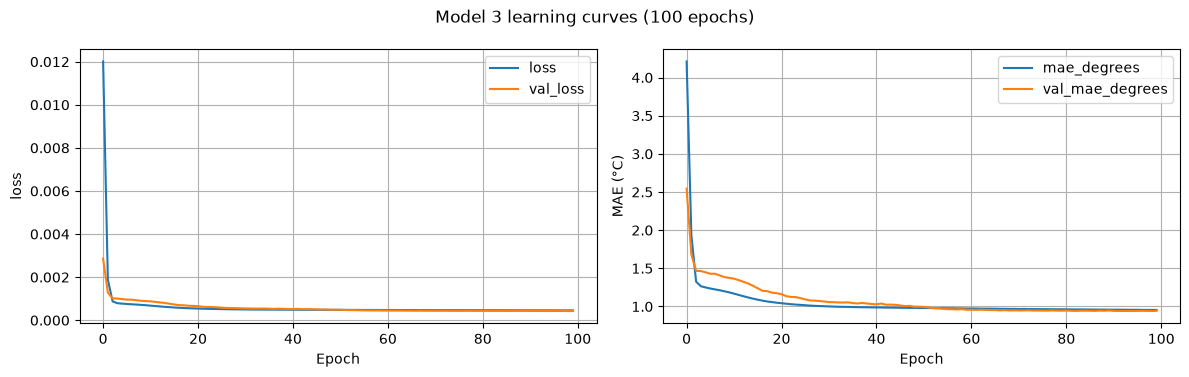

In [ ]:
history_3 = train_model(model_3,
                        [X_train, shift_targets(X_train, y_train)], y_train_scaled,
                        [X_val, shift_targets(X_val, y_val)], y_val_scaled)
plot_learning_curve(history_3, "Model 3 learning curves")

The encoder-decoder trains to a validation MAE a little under 1.0 degrees, slightly better than model 1 reached on the same 12 month task. The curves look healthy, the training and validation lines stay together, and like model 2 it uses all 100 epochs.

There is one important caveat in reading this plot. The validation MAE here is measured with teacher forcing, because that is how ``fit`` runs the model, so the decoder is being handed a real temperature at every step. That is not the job it has to do on the test set, and the next section shows how much difference that makes.

### Section 4.3: Test Set Performance

At test time the ground truth is not available to the decoder, so it has to consume its own output. The function below starts the decoder off with the single last observed month, and on each pass appends the predictions it just made to the decoder input, so after ``horizon`` passes the returned sequence is ``horizon`` months long and everything after the first month was generated from predicted values only.

Re-running the encoder on every pass is slightly wasteful, but the number of passes is small and it keeps this to a few lines with no separate inference model to keep in step with the trained one.

In [ ]:
def forecast_encoder_decoder(model, X, horizon):
    # Grow the decoder input one month at a time out of the model's own predictions
    decoder_inputs = X[:, -1:]
    for _ in range(horizon):
        y_pred = model([X, decoder_inputs], training=False) * SCALE
        decoder_inputs = tf.concat([X[:, -1:], y_pred], axis=1)
    return y_pred

y_pred_3 = forecast_encoder_decoder(model_3, X_test, TARGET_LENGTH)
mae_3 = evaluate_mae(y_test, y_pred_3)
print(f"Model 3 test MAE, 12 months autoregressive: {mae_3:.4f} °C")

Model 3 test MAE, 12 months autoregressive: 1.2130 °C


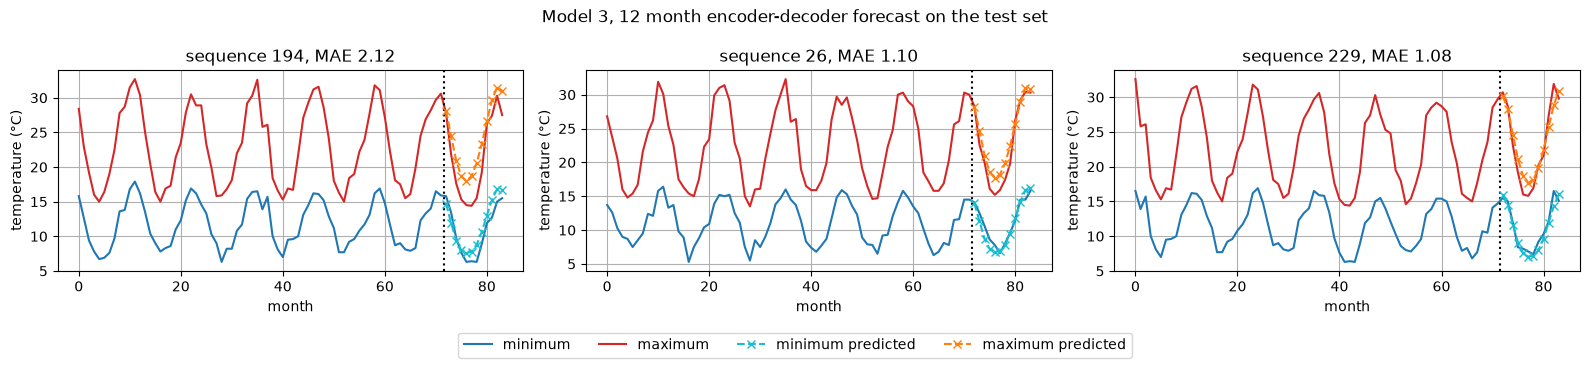

In [ ]:
display_temperatures(X_test, y_test, "Model 3, 12 month encoder-decoder forecast on the test set",
                     y_pred=y_pred_3)

Run the way it will actually be used, with the decoder consuming its own output, model 3 gets 1.21 degrees. That is the worst of the three models, despite it having had the best validation MAE of the three while training. The distance between the teacher forced validation MAE in the plot above and this 1.21 is exposure bias: during training every decoder step was handed a real observation, so the model never had to cope with its own mistakes, and on the test set it has to do exactly that from the second month onwards.

The sampled sequences look much like the other two models', with the same smooth seasonal template and the same trouble on sequence 194, so the extra machinery has not bought anything here. That is a fair result rather than a disappointing one. Encoder-decoders earn their keep when the output is a different kind of object from the input, a sentence in another language being the standard example. Here the output is just more of the same series, which the two simpler models already handle, and all the encoder-decoder adds is a mismatch between how it trains and how it runs.

## Section 5: Comparing Prediction Horizons

Models 2 and 3 both generate their forecasts one month at a time, so neither needs retraining to forecast further ahead. All that changes is how many months we ask for and how many months of ground truth we slice out of ``test_seq``, which is what the spare months at the end of the test sequences were being saved for: the (72, 24) setting uses all 96.

As a reference point we also include a forecast that involves no learning at all. ``seasonal_naive`` repeats the last 12 observed months, tiled out to whatever horizon is asked for. Because temperature is almost perfectly annual this is a genuinely hard baseline to beat, and it is the right thing to compare against when the question is how much the models actually learned rather than how low the MAE looks.

In [ ]:
def seasonal_naive(X, horizon):
    # Reference forecast with no learning: repeat the last 12 observed months
    return tf.tile(X[:, -12:], [1, horizon // 12 + 1, 1])[:, :horizon]

horizons = [12, 15, 18, 21, 24]
rows = []
for horizon in horizons:
    _, y_true = split_sequences(test_seq, INPUT_LENGTH, horizon)
    rows.append({
        "horizon": horizon,
        "model 2 (looped)": evaluate_mae(y_true, forecast_recursively(model_2, X_test, horizon)),
        "model 3 (encoder-decoder)": evaluate_mae(y_true, forecast_encoder_decoder(model_3, X_test, horizon)),
        "seasonal naive": evaluate_mae(y_true, seasonal_naive(X_test, horizon)),
    })

horizon_mae = pd.DataFrame(rows).set_index("horizon")
horizon_mae.round(4)

,model 2 (looped),model 3 (encoder-decoder),seasonal naive
horizon,,,
12,1.0876,1.2130,1.2350
15,1.0979,1.2272,1.2327
18,1.1101,1.2545,1.2314
21,1.1214,1.2843,1.2320
24,1.1306,1.3025,1.2338


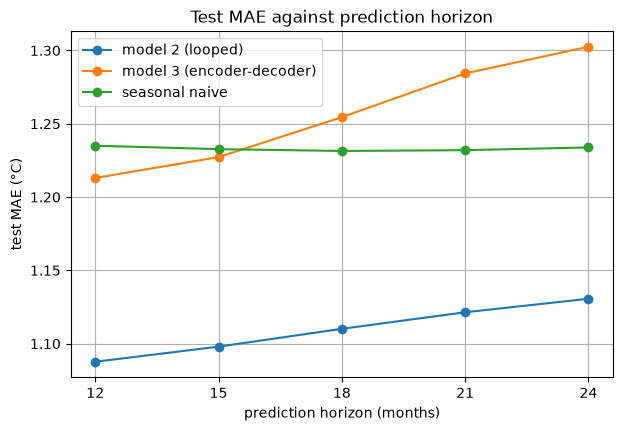

In [ ]:
horizon_mae.plot(marker="o", grid=True, figsize=(7, 4.5),
                 xlabel="prediction horizon (months)", ylabel="test MAE (°C)",
                 title="Test MAE against prediction horizon")
plt.xticks(horizons)
plt.show()

**Which model deteriorates fastest.** Model 3, by roughly a factor of two. Going from a 12 month to a 24 month horizon, its MAE climbs 0.090 degrees, from 1.213 to 1.303, while model 2 climbs 0.043, from 1.088 to 1.131. The two lines diverge rather than running parallel, and the ordering never changes: model 2 is better at every horizon tested and its lead grows as the horizon does.

The cause is the exposure bias from Section 4.3 given more room to act. Model 3's decoder was trained on 12 step sequences and is being asked for 24, so every step past the twelfth is unfamiliar twice over, both because it is consuming predicted values and because the decoder is further along its own recurrence than it ever went in training. Model 2 has no sense of position at all. It does the same one month job on every iteration, so asking for 24 iterations rather than 12 is not a new task for it, just more of the same one.

**The baseline is the sobering column.** Repeating the last twelve observed months scores 1.235 at horizon 12 and stays flat at about 1.233 all the way out to 24, because it exploits the annual period exactly and so has nothing to degrade. Model 2 beats it at every horizon, but only by about 0.10 to 0.15 degrees, an 8 to 12 per cent improvement. Model 3 beats it at horizon 12 by 0.02 degrees, which is effectively a tie, draws with it at 15, and is worse than it from 18 months on.

So to a first approximation both networks have learned the annual cycle, which the baseline gets for nothing, and not a great deal beyond it.

**How good is the transfer from one station to another?** Good enough to be useful, and better than doing nothing, but the margin over a one line baseline is small. It is also worth being clear about why the transfer works at all, because it is less impressive than it first sounds. The models are never asked to know anything about Bickley in advance: every prediction arrives with 72 months of Bickley's own history as input, so the station's level and its seasonal amplitude can be read straight off that. The roughly two degree offset between Bickley's mean maximum and the training stations' is handled by the input, not learned. What actually transfers from Perth is the general shape of a Western Australian annual temperature cycle, and that shape is close enough between the two places to be reused.

The same reasoning caps how well any of this can do. Once you know the annual cycle and the station's level, what is left is month to month weather noise, and nothing in a 72 month history predicts that. A model whose predictions are a smooth seasonal curve is, in that sense, already close to the best a model of this kind can do on this data.

## Section 6: Variational Autoencoder

### Section 6.1: Data Preparation

For the last part we leave forecasting behind and train a VAE to synthesize maximum temperature sequences. The inputs are the full 84 month sequences from ``train_seq`` with only component 1 kept, which gives a flat vector of 84 numbers per sequence, and the maximum temperatures from ``val_seq`` are the validation set.

The same ``SCALE`` constant from the forecasting models is reused here, and for a VAE the scaling does more work than it did there. A VAE's loss is a reconstruction term plus a latent term, and the ratio between them decides how hard the codings get pushed towards a unit Gaussian. Left in degrees, the squared reconstruction error runs into the hundreds while the latent term stays of order one, so the latent term would count for nothing and the model would drift into behaving like a plain autoencoder whose codings we cannot sample from. Dividing by 40 puts the sequences in roughly [0.4, 0.9] and brings the two terms onto the same footing, which is the prerequisite for balancing them properly. Getting that balance right takes one more step, and Section 6.2 covers it. The same constant multiplies the generated sequences back into degrees at the end.

In [ ]:
CODINGS_SIZE = 8
LATENT_WEIGHT = 0.1

T_train = train_seq[:, :, 1] / SCALE
T_val = val_seq[:, :, 1] / SCALE

print(f"T_train: {T_train.shape}  T_val: {T_val.shape}")
print(f"scaled range: {float(tf.reduce_min(T_train)):.3f} to {float(tf.reduce_max(T_train)):.3f}")

T_train: (1522, 84)  T_val: (313, 84)
scaled range: 0.405 to 0.907


### Section 6.2: Model Architecture

The model follows the Dense VAE from Chapter 17. The encoder is two ``Dense`` layers narrowing 84 months down to 32 units, then two parallel ``Dense`` layers producing the mean and the log variance of the codings distribution, then a ``Sampling`` layer that draws a codings vector from it using the reparameterisation trick. The decoder mirrors that back out to 84 numbers, with a linear output layer rather than a sigmoid because these are temperatures and not pixels in [0, 1].

A codings size of 8 is used. A maximum temperature sequence is close to a sine wave with only a few free parameters behind it: the station's mean level, the amplitude of its seasonal swing, which calendar month the sequence begins on, and some year to year wobble. Eight dimensions leaves room for those without being so wide that the encoder can memorise a sequence outright and stop needing the codings distribution.

The latent loss is the KL divergence from Chapter 17, and it is the one place where the book's code needs changing rather than adapting. Chapter 17 computes it on the functional model's symbolic tensors and attaches it with ``variational_ae.add_loss(...)``, which Keras 3 no longer allows: ``tf.exp`` on a ``KerasTensor`` raises, and ``add_loss`` on a functional model raises ``NotImplementedError``. Moving the same expression inside the ``Sampling`` layer's ``call`` fixes both, and that layer already has the mean and the log variance in hand. The formula itself is unchanged.

It also needs a weight, which is the part that took the most work. Géron divides by 784 because that is the number of MNIST pixels and Keras has already averaged the reconstruction loss over them, so the direct translation here is to divide by 84. That does not work. Scaled maximum temperatures have a variance of about 0.016, several times smaller than MNIST pixels, so the reconstruction term is weaker while the latent term is unchanged. The latent term then wins outright, the codings collapse onto the prior, and the decoder learns to ignore them: reconstruction error sits at about 3.9 degrees and every generated sequence is the same near flat line, with a peak to trough range of 2.6 degrees against 17.2 for real data.

``LATENT_WEIGHT`` fixes that and is not a delicate setting: anything from about 0.2 down to 0.02 gave reconstruction errors between 1.2 and 1.8 degrees with realistic looking samples. Pushing it to 0.01 breaks the model the other way, as the codings stop matching the unit Gaussian we sample from and the sequences come out around six degrees too cold. We use 0.1, in the middle of the working range, which keeps the latent term doing real work rather than reducing the VAE to an ordinary autoencoder.

In [ ]:
class Sampling(tf.keras.layers.Layer):
    def __init__(self, sequence_length, latent_weight, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.latent_weight = latent_weight

    def call(self, inputs):
        mean, log_var = inputs
        # Latent loss from chapter 17, normalised by the sequence length and reweighted
        latent_loss = -0.5 * tf.reduce_sum(
            1 + log_var - tf.exp(log_var) - tf.square(mean), axis=-1)
        self.add_loss(self.latent_weight * tf.reduce_mean(latent_loss) / self.sequence_length)
        return tf.random.normal(tf.shape(log_var)) * tf.exp(log_var / 2) + mean

def build_vae(codings_size=CODINGS_SIZE, latent_weight=LATENT_WEIGHT, n_units=(64, 32),
              learning_rate=1e-3):
    tf.keras.utils.set_random_seed(42)

    inputs = tf.keras.layers.Input(shape=[84])
    Z = tf.keras.layers.Dense(n_units[0], activation="relu")(inputs)
    Z = tf.keras.layers.Dense(n_units[1], activation="relu")(Z)
    codings_mean = tf.keras.layers.Dense(codings_size)(Z)
    codings_log_var = tf.keras.layers.Dense(codings_size)(Z)
    codings = Sampling(84, latent_weight)([codings_mean, codings_log_var])
    encoder = tf.keras.Model(inputs=[inputs],
                             outputs=[codings_mean, codings_log_var, codings])

    decoder_inputs = tf.keras.layers.Input(shape=[codings_size])
    x = tf.keras.layers.Dense(n_units[1], activation="relu")(decoder_inputs)
    x = tf.keras.layers.Dense(n_units[0], activation="relu")(x)
    outputs = tf.keras.layers.Dense(84)(x)
    decoder = tf.keras.Model(inputs=[decoder_inputs], outputs=[outputs])

    _, _, codings = encoder(inputs)
    vae = tf.keras.Model(inputs=[inputs], outputs=[decoder(codings)])

    vae.compile(loss="mse", optimizer=tf.keras.optimizers.Nadam(learning_rate=learning_rate),
                metrics=[mae_degrees])
    return vae, encoder, decoder

vae, variational_encoder, variational_decoder = build_vae()
vae.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_3 (Functional)       │ [(None, 8), (None, 8), │         8,048 │
│                                 │ (None, 8)]             │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_4 (Functional)       │ (None, 84)             │         7,860 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,908 (62.14 KB)

 Trainable params: 15,908 (62.14 KB)

 Non-trainable params: 0 (0.00 B)

### Section 6.3: Training

The VAE is trained to reconstruct its own input for 100 epochs with early stopping on the validation loss, again with no verbose output. The reconstruction MAE in the right hand panel says how closely the model can reproduce a real sequence it was shown, which is a useful sanity check but not the same thing as whether the sequences it invents look plausible.

I0000 00:00:1789960767.146891  250226 service.cc:153] XLA service 0x765c2c02bc70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1789960767.146911  250226 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5070, Compute Capability 12.0a (Driver: 13.1.0; Runtime: 13.3.0; Toolkit: 13.0.0; DNN: 9.23.1)
I0000 00:00:1789960767.166336  250226 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1789960767.285985  250226 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_152041__.15


I0000 00:00:1789960769.691782  250226 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
I0000 00:00:1789960769.877429  250230 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_152041__.15


I0000 00:00:1789960772.564887  250226 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_152561__.7


I0000 00:00:1789960773.026830  250230 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_152561__.7


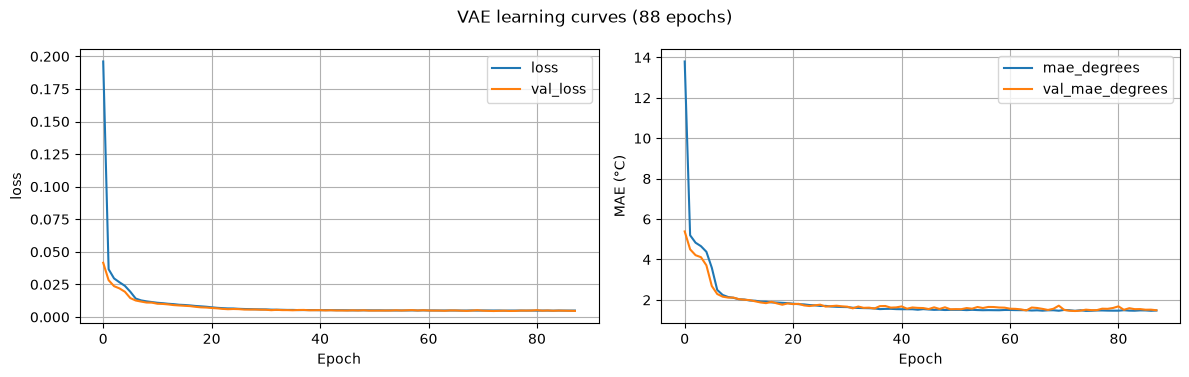

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)
history_vae = vae.fit(T_train, T_train, epochs=100, batch_size=32,
                      validation_data=(T_val, T_val),
                      callbacks=[early_stopping], verbose=0)
plot_learning_curve(history_vae, "VAE learning curves")

The reconstruction MAE falls to about one and a half degrees a month and the training and validation curves sit almost on top of each other for the whole run, which is reassuring given the validation sequences come from a different station entirely. Training stopped at epoch 88, so early stopping did fire here with a few epochs of the budget left.

### Section 6.4: Synthesizing Sequences

To generate new sequences we skip the encoder entirely, draw six codings vectors from the unit Gaussian that the latent loss trained the codings to follow, push them through the decoder, and multiply by ``SCALE`` to get back to degrees.

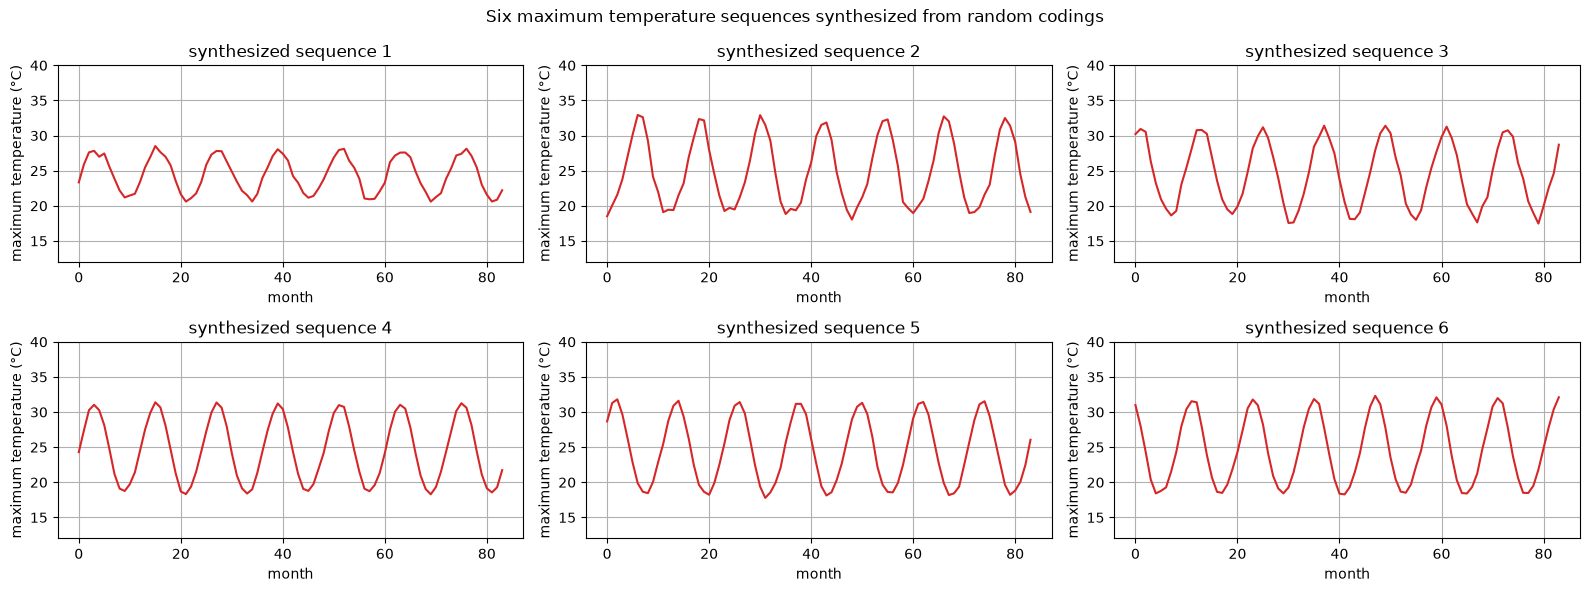

In [ ]:
tf.random.set_seed(42)

codings = tf.random.normal(shape=[6, CODINGS_SIZE])
synthesized = variational_decoder(codings) * SCALE

plt.figure(figsize=(16, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.plot(np.arange(84), synthesized[i], color="tab:red")
    plt.title(f"synthesized sequence {i + 1}")
    plt.xlabel("month")
    plt.ylabel("maximum temperature (°C)")
    plt.ylim(12, 40)
    plt.grid(True)
plt.suptitle("Six maximum temperature sequences synthesized from random codings")
plt.tight_layout()
plt.show()

For comparison, here are six real maximum temperature sequences from the training set, drawn on the same axes.

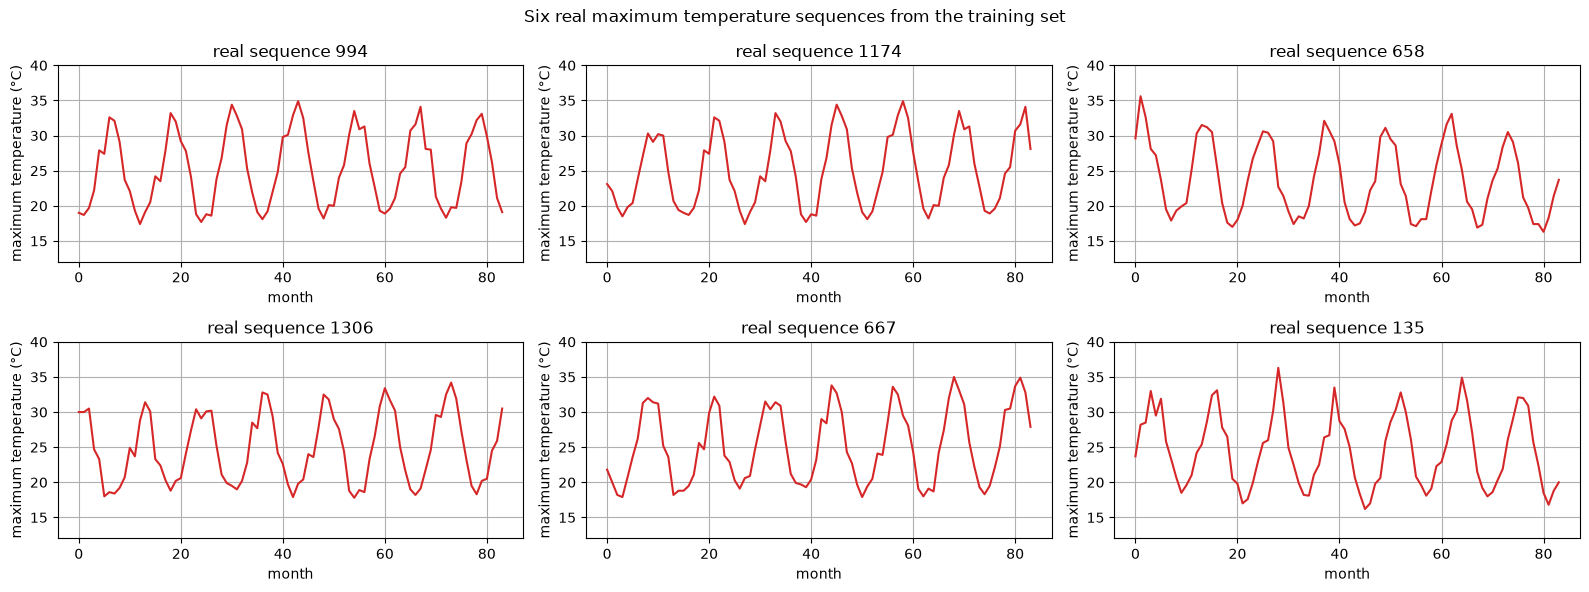

In [ ]:
rng = np.random.default_rng(42)
real_indices = rng.choice(train_seq.shape[0], size=6, replace=False)

plt.figure(figsize=(16, 6))
for i, index in enumerate(real_indices):
    plt.subplot(2, 3, i + 1)
    plt.plot(np.arange(84), train_seq[index, :, 1], color="tab:red")
    plt.title(f"real sequence {index}")
    plt.xlabel("month")
    plt.ylabel("maximum temperature (°C)")
    plt.ylim(12, 40)
    plt.grid(True)
plt.suptitle("Six real maximum temperature sequences from the training set")
plt.tight_layout()
plt.show()

Eyeballing six curves only goes so far, so we also compare a few summary statistics of 300 synthesized sequences against the real training sequences. The month to month change and the peak to trough range are the two that matter most: the first says whether the curve is as smooth as a real temperature record, and the second says whether the seasonal swing has survived.

In [ ]:
def sequence_stats(sequences):
    return {
        "mean": float(tf.reduce_mean(sequences)),
        "std": float(tf.math.reduce_std(sequences)),
        "mean monthly change": float(tf.reduce_mean(tf.abs(sequences[:, 1:] - sequences[:, :-1]))),
        "mean peak to trough": float(tf.reduce_mean(
            tf.reduce_max(sequences, axis=1) - tf.reduce_min(sequences, axis=1))),
    }

tf.random.set_seed(42)
many_codings = tf.random.normal(shape=[300, CODINGS_SIZE])

pd.DataFrame({
    "real": sequence_stats(train_seq[:, :, 1]),
    "synthesized": sequence_stats(variational_decoder(many_codings) * SCALE),
}).round(2)

,real,synthesized
mean,24.70,24.72
std,5.11,4.41
mean monthly change,2.48,2.02
mean peak to trough,17.24,12.81


**Do they look realistic? Partly.** All six have the right basic anatomy: a clean annual cycle, seven repetitions across the 84 months, peaks in the high twenties to low thirties and troughs in the high teens. They also differ from one another in level, in amplitude and in which calendar month they happen to start on, which tells us the codings really are carrying those properties rather than the decoder having memorised one sequence.

They are too clean, though, and the table puts numbers on it. The mean is almost exact, 24.72 against 24.70, so the model has the overall climate right. But the mean month to month change is 2.02 degrees against 2.48 for real sequences, and the mean peak to trough range is 12.81 against 17.24. Both point the same way: the synthesized curves are smoother and flatter than real ones. Comparing the two sets of plots directly makes it obvious. The real sequences are visibly ragged, with a warm month interrupting a cooling run and whole years that are clearly hotter or cooler than their neighbours, while the synthesized ones are close to pure sinusoids that repeat almost identically year after year.

This is expected behaviour rather than a bug. The VAE is trained on a squared error reconstruction loss, and for any month whose weather noise the model cannot predict, the option that minimises squared error is to predict the average and leave the noise out. Anything genuinely unpredictable therefore gets smoothed away, which is the same reason VAE generated images come out blurry.

Synthesized sequence 1 shows the other failure mode. Its peak to trough range is only about 8 degrees, well below anything in the real data. The prior we sample from puts some probability on regions of the codings space that the decoder has not learned well, and occasionally a sample lands in one.

## Section 7: Summary and Conclusion

In this project we forecast monthly mean minimum and maximum temperatures at one weather station using models trained on three others, then trained a VAE to invent maximum temperature sequences. Each result was discussed where it appeared, so this is a brief summary.

| model | task | test MAE (°C) |
|---|---|---|
| model 1 | 12 months in one go | 1.125 |
| model 2 | 1 month | 0.947 |
| model 2 | 12 months by looping | 1.088 |
| model 3 | 12 months, encoder-decoder | 1.213 |
| seasonal naive | 12 months, no learning at all | 1.235 |

**Activation and scaling are one decision, not two.** The most important choice here was not any of the three architectures but getting the GRU activation and the data scaling to agree. In degrees, a default ``tanh`` network never gets past about 3.6 degrees, roughly what predicting a flat average achieves. One global scaling constant takes the same network to 1.12, and ``relu`` on unscaled data reaches about 1.18. Either answer works; doing neither leaves the network three times worse.

**Simpler was better.** The three architectures finished in the opposite order to their complexity, and the encoder-decoder came last despite having the best validation MAE while training. That gap is the price of teacher forcing. When the output is just more of the same series, an encoder-decoder does not pay for the train and test mismatch it introduces, and it also degrades about twice as fast as model 2 when the horizon grows.

**Most of what was learned is the annual cycle.** Repeating the last twelve observed months scores 1.235 without any learning at all. Model 2 beats that by 8 to 12 per cent at every horizon and model 3 barely matches it, so the networks have largely learned the seasonal shape and not a great deal more. The Perth to Bickley transfer works because each prediction arrives with 72 months of Bickley's own history, so the station's level comes from the input rather than from training.

**The VAE.** The synthesized sequences are recognisably temperature records with the right mean and with level, amplitude and phase varying between samples, but they are too smooth, because a squared error loss makes predicting the average the safest option for anything unpredictable. The lesson worth keeping is that copying the textbook's latent loss normalisation straight across collapsed the model completely: this data has several times less variance than MNIST, so the same recipe over-weights the latent term. A recipe that works on images is not automatically one that works on different data at a different scale.